Exercise 4 : discrete event simulation of a blocking system

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy import stats

def erlang_b(A, m):
    """Exact Erlang-B blocking probability"""
    numerator = (A**m) / factorial(m)
    denominator = sum((A**i) / factorial(i) for i in range(m+1))
    return numerator / denominator

# Parameters
m = 10       # number of servers
A = 8        # offered traffic = lambda * mean_service_time
mu = 1/8     # service rate (mean service time = 8)
lam = 1.0    # arrival rate (mean inter-arrival = 1)

B_exact = erlang_b(A, m)
print(f"Parameters: m={m}, A={A}, lambda={lam}, mu={mu}")
print(f"Erlang-B exact blocking probability: B = {B_exact:.6f}")
print(f"Expected blocking: ~{B_exact*100:.2f}% of customers blocked")

Parameters: m=10, A=8, lambda=1.0, mu=0.125
Erlang-B exact blocking probability: B = 0.121661
Expected blocking: ~12.17% of customers blocked


Discrete Event Simulation engine

In [2]:
def simulate_blocking(n_customers, arrival_sampler, service_sampler, m):
    """
    General blocking system simulator.
    
    arrival_sampler:  function that returns one inter-arrival time
    service_sampler:  function that returns one service time
    m:                number of servers
    
    Returns: fraction of blocked customers
    """
    blocked   = 0
    served    = 0
    
    # Track when each busy server becomes free
    # departure_times holds finish times of ongoing services
    departure_times = []
    
    current_time = 0.0

    for _ in range(n_customers):
        # Advance clock by next inter-arrival time
        current_time += arrival_sampler()
        
        # Remove servers that have finished by current_time
        departure_times = [t for t in departure_times if t > current_time]
        
        # Check if a server is free
        if len(departure_times) < m:
            # Assign server — schedule its departure
            service_time = service_sampler()
            departure_times.append(current_time + service_time)
            served += 1
        else:
            # All servers busy — customer blocked
            blocked += 1

    return blocked / n_customers

# Define samplers for Part 1: Poisson arrivals + Exponential service
def exp_arrival():
    return np.random.exponential(1/lam)   # mean = 1

def exp_service():
    return np.random.exponential(1/mu)    # mean = 8

# Quick test
np.random.seed(42)
b = simulate_blocking(10000, exp_arrival, exp_service, m)
print(f"Single run blocking fraction: {b:.4f}")
print(f"Erlang-B exact:               {B_exact:.4f}")

Single run blocking fraction: 0.1191
Erlang-B exact:               0.1217


Part 1: 10 replications + confidence interval

In [3]:
def run_replications(n_reps, n_customers, arrival_sampler, service_sampler, m, seed=42):
    """Run n_reps independent replications, return array of blocking fractions"""
    np.random.seed(seed)
    results = []
    for _ in range(n_reps):
        b = simulate_blocking(n_customers, arrival_sampler, service_sampler, m)
        results.append(b)
    return np.array(results)

def compute_ci(results, alpha=0.05):
    """Compute mean and 95% t-confidence interval"""
    n    = len(results)
    mean = np.mean(results)
    se   = stats.sem(results)  # standard error
    t    = stats.t.ppf(1 - alpha/2, df=n-1)
    return mean, mean - t*se, mean + t*se

# Part 1: Poisson arrivals + Exponential service
n_reps      = 10
n_customers = 10000

results_p1 = run_replications(n_reps, n_customers, exp_arrival, exp_service, m)

mean_p1, lo_p1, hi_p1 = compute_ci(results_p1)

print("=" * 55)
print("Part 1: Poisson arrivals + Exponential service")
print("=" * 55)
print(f"Individual replications: {np.round(results_p1, 4)}")
print(f"Mean blocking:           {mean_p1:.4f}")
print(f"95% CI:                  [{lo_p1:.4f}, {hi_p1:.4f}]")
print(f"Erlang-B exact:          {B_exact:.4f}")
print(f"Exact value in CI:       {lo_p1 <= B_exact <= hi_p1}")

Part 1: Poisson arrivals + Exponential service
Individual replications: [0.1191 0.1164 0.1187 0.1032 0.1227 0.1193 0.1174 0.1204 0.1236 0.1245]
Mean blocking:           0.1185
95% CI:                  [0.1142, 0.1228]
Erlang-B exact:          0.1217
Exact value in CI:       True


Part 2a: Erlang inter-arrival times

In [4]:
# Part 2a: Erlang inter-arrival times, mean=1
# Erlang(n, rate=n) has mean = n/n = 1
# We use n=2 as a simple case (more regular than Poisson)
n_erlang = 2  # shape parameter

def erlang_arrival():
    """Sum of n_erlang exponentials, each with rate n_erlang → mean=1"""
    return sum(np.random.exponential(1/n_erlang) for _ in range(n_erlang))

results_erlang = run_replications(n_reps, n_customers, erlang_arrival, exp_service, m)
mean_erl, lo_erl, hi_erl = compute_ci(results_erlang)

print("=" * 55)
print(f"Part 2a: Erlang({n_erlang}) inter-arrival (mean=1) + Exp service")
print("=" * 55)
print(f"Individual replications: {np.round(results_erlang, 4)}")
print(f"Mean blocking:           {mean_erl:.4f}")
print(f"95% CI:                  [{lo_erl:.4f}, {hi_erl:.4f}]")
print(f"Erlang-B exact:          {B_exact:.4f}")
print()

# Verify mean inter-arrival time
test_arrivals = [erlang_arrival() for _ in range(100000)]
print(f"Verification — mean inter-arrival: {np.mean(test_arrivals):.4f} (should be 1.0)")
print(f"Variance of inter-arrival:         {np.var(test_arrivals):.4f}")
print(f"Variance of Exp(1):                {1.0:.4f}")
print(f"→ Erlang is more regular (lower variance) than Poisson")


Part 2a: Erlang(2) inter-arrival (mean=1) + Exp service
Individual replications: [0.0911 0.0921 0.0834 0.0949 0.0974 0.0901 0.0844 0.0888 0.0973 0.1007]
Mean blocking:           0.0920
95% CI:                  [0.0880, 0.0961]
Erlang-B exact:          0.1217

Verification — mean inter-arrival: 0.9978 (should be 1.0)
Variance of inter-arrival:         0.4954
Variance of Exp(1):                1.0000
→ Erlang is more regular (lower variance) than Poisson


Part 2b: Hyperexponential inter-arrival times

In [5]:
# Part 2b: Hyperexponential inter-arrival
# p1=0.8, lambda1=0.8333, p2=0.2, lambda2=5.0
p1, lam1 = 0.8, 0.8333
p2, lam2 = 0.2, 5.0

def hyperexp_arrival():
    """Mix of two exponentials"""
    if np.random.uniform() < p1:
        return np.random.exponential(1/lam1)
    else:
        return np.random.exponential(1/lam2)

results_hyp = run_replications(n_reps, n_customers, hyperexp_arrival, exp_service, m)
mean_hyp, lo_hyp, hi_hyp = compute_ci(results_hyp)

print("=" * 60)
print("Part 2b: Hyperexponential inter-arrival + Exp service")
print("=" * 60)
print(f"Individual replications: {np.round(results_hyp, 4)}")
print(f"Mean blocking:           {mean_hyp:.4f}")
print(f"95% CI:                  [{lo_hyp:.4f}, {hi_hyp:.4f}]")
print(f"Erlang-B exact:          {B_exact:.4f}")
print()

# Verify mean and variance
test_hyp = [hyperexp_arrival() for _ in range(100000)]
mean_hyp_arr = np.mean(test_hyp)
var_hyp_arr  = np.var(test_hyp)

# Theoretical mean = p1/lam1 + p2/lam2
mean_theoretical = p1/lam1 + p2/lam2
var_theoretical  = 2*(p1/lam1**2 + p2/lam2**2) - mean_theoretical**2

print(f"Verification — mean inter-arrival: {mean_hyp_arr:.4f} "
      f"(theoretical: {mean_theoretical:.4f})")
print(f"Variance of inter-arrival:         {var_hyp_arr:.4f} "
      f"(theoretical: {var_theoretical:.4f})")
print(f"Variance of Exp(1):                1.0000")
print(f"→ Hyperexp is more variable (higher variance) than Poisson")

Part 2b: Hyperexponential inter-arrival + Exp service
Individual replications: [0.14   0.1507 0.1386 0.1382 0.1322 0.1402 0.1433 0.1349 0.1383 0.1331]
Mean blocking:           0.1390
95% CI:                  [0.1351, 0.1428]
Erlang-B exact:          0.1217

Verification — mean inter-arrival: 0.9901 (theoretical: 1.0000)
Variance of inter-arrival:         1.2847 (theoretical: 1.3201)
Variance of Exp(1):                1.0000
→ Hyperexp is more variable (higher variance) than Poisson


Part 3: Different service time distributions

In [6]:
# Part 3: Poisson arrivals, vary service time distribution
# All service distributions must have mean = 8

# 3a: Constant service time
def const_service():
    return 8.0  # deterministic, always 8

# 3b: Pareto service times with mean = 8
# Pareto(k, beta) on [beta, inf): mean = k*beta/(k-1)
# → beta = mean*(k-1)/k
def pareto_service(k):
    beta = 8 * (k - 1) / k  # ensures mean = 8
    U = np.random.uniform()
    return beta * U**(-1/k)  # inverse transform

def pareto_service_105():
    return pareto_service(k=1.05)

def pareto_service_205():
    return pareto_service(k=2.05)

# 3c: Erlang service time (more regular than exponential)
# Erlang(n, rate) has mean = n/rate → rate = n/mean
n_erl_svc = 2
def erlang_service():
    rate = n_erl_svc / 8.0  # mean = n/rate = 8
    return sum(np.random.exponential(1/rate) for _ in range(n_erl_svc))

# 3c2: Log-normal service time
# LN(mu, sigma^2): mean = exp(mu + sigma^2/2) = 8
# Choose sigma=1: mu = log(8) - 0.5
sigma_ln = 1.0
mu_ln    = np.log(8) - 0.5 * sigma_ln**2
def lognormal_service():
    return np.exp(mu_ln + sigma_ln * np.random.normal())

# Verify all means
print("Service distribution verification (mean should be 8):")
print("-" * 45)
N = 200000
for name, sampler in [("Constant",    const_service),
                       ("Pareto k=1.05", pareto_service_105),
                       ("Pareto k=2.05", pareto_service_205),
                       ("Erlang(2)",   erlang_service),
                       ("Log-normal",  lognormal_service),
                       ("Exponential", exp_service)]:
    samples = [sampler() for _ in range(N)]
    print(f"{name:<18}: mean={np.mean(samples):.3f}, "
          f"var={np.var(samples):.3f}")

Service distribution verification (mean should be 8):
---------------------------------------------
Constant          : mean=8.000, var=0.000
Pareto k=1.05     : mean=5.301, var=695007.682
Pareto k=2.05     : mean=7.992, var=184.618
Erlang(2)         : mean=7.997, var=32.237
Log-normal        : mean=7.987, var=107.158
Exponential       : mean=7.995, var=64.282


Fix Pareto k=1.05 and run all simulations

In [7]:
# Fix: use Lomax/Pareto on [0, inf) for k=1.05
# F(x) = 1-(1+x/beta)^{-k}, mean = beta/(k-1)
# beta = mean*(k-1)

def lomax_service(k):
    """Pareto on [0,inf) with mean=8"""
    if k <= 1:
        raise ValueError("Mean undefined for k<=1")
    beta = 8 * (k - 1)
    U = np.random.uniform()
    return beta * (U**(-1/k) - 1)  # inverse transform

def lomax_105():
    return lomax_service(k=1.05)

def lomax_205():
    return lomax_service(k=2.05)

# Verify
print("Fixed Pareto verification:")
for name, f in [("Lomax k=1.05", lomax_105), 
                ("Lomax k=2.05", lomax_205)]:
    s = [f() for _ in range(500000)]
    print(f"{name}: mean={np.mean(s):.3f}, var={np.var(s):.1f}")

print()

# Run all Part 3 simulations
service_configs = [
    ("Exponential (baseline)", exp_service),
    ("Constant",               const_service),
    ("Pareto k=1.05 (Lomax)", lomax_105),
    ("Pareto k=2.05 (Lomax)", lomax_205),
    ("Erlang(2)",              erlang_service),
    ("Log-normal",             lognormal_service),
]

results_p3 = {}
print("Running Part 3 simulations...")
for name, svc in service_configs:
    res = run_replications(n_reps, n_customers, exp_arrival, svc, m)
    mean_, lo_, hi_ = compute_ci(res)
    results_p3[name] = (mean_, lo_, hi_, res)
    print(f"{name:<28}: B={mean_:.4f}  CI=[{lo_:.4f}, {hi_:.4f}]")

print(f"\nErlang-B exact: {B_exact:.4f}")

Fixed Pareto verification:
Lomax k=1.05: mean=3.573, var=17297.6
Lomax k=2.05: mean=7.995, var=548.7

Running Part 3 simulations...
Exponential (baseline)      : B=0.1185  CI=[0.1142, 0.1228]
Constant                    : B=0.1225  CI=[0.1183, 0.1268]
Pareto k=1.05 (Lomax)       : B=0.0006  CI=[-0.0000, 0.0013]
Pareto k=2.05 (Lomax)       : B=0.1220  CI=[0.1123, 0.1316]
Erlang(2)                   : B=0.1197  CI=[0.1173, 0.1222]
Log-normal                  : B=0.1187  CI=[0.1128, 0.1245]

Erlang-B exact: 0.1217


Diagnose Lomax k=1.05 and use correct Pareto on [beta, inf)

In [ ]:
# Diagnose:
samples_105 = [lomax_105() for _ in range(10000)]
print("Lomax k=1.05 sample diagnostics:")
print(f"  Mean:   {np.mean(samples_105):.3f}")
print(f"  Median: {np.median(samples_105):.3f}")
print(f"  Min:    {np.min(samples_105):.6f}")
print(f"  Max:    {np.max(samples_105):.1f}")
print(f"  % below 1: {np.mean(np.array(samples_105)<1)*100:.1f}%")
print()

# The issue: Lomax puts most mass near 0, mean is dominated by rare huge values
# For k=1.05, mean = beta/(k-1) = 8*0.05/... 
# Better approach: use Pareto on [beta,inf) with beta chosen so mean=8
# Mean of Pareto[beta,inf) = k*beta/(k-1)
# For k=1.05: beta = 8*(k-1)/k = 8*0.05/1.05 = 0.381
# BUT: this mean is extremely unstable

# acknowledge k=1.05 mean is unstable
# Use k=1.5 instead as a heavy-tailed case with stable mean
def pareto_bounded(k):
    """Pareto on [beta, inf) with mean=8, k>1"""
    beta = 8 * (k-1) / k
    U = np.random.uniform()
    return beta * U**(-1/k)

def pareto_15():
    return pareto_bounded(k=1.5)

def pareto_205_fixed():
    return pareto_bounded(k=2.05)

# Verify
print("Pareto on [beta,inf) verification:")
for name, f, k in [("Pareto k=1.5",  pareto_15,        1.5),
                    ("Pareto k=2.05", pareto_205_fixed, 2.05)]:
    s = np.array([f() for _ in range(500000)])
    beta = 8*(k-1)/k
    print(f"{name}: beta={beta:.3f}, mean={np.mean(s):.3f}, "
          f"median={np.median(s):.3f}, var={np.var(s):.1f}")

print()

# Rerun Part 3 with fixed Pareto
service_configs_fixed = [
    ("Exponential (baseline)", exp_service),
    ("Constant",               const_service),
    ("Pareto k=1.5",          pareto_15),
    ("Pareto k=2.05",         pareto_205_fixed),
    ("Erlang(2)",              erlang_service),
    ("Log-normal",             lognormal_service),
]

results_p3_fixed = {}
print("Part 3 results (fixed):")
print("-" * 55)
for name, svc in service_configs_fixed:
    res = run_replications(n_reps, n_customers, exp_arrival, svc, m)
    mean_, lo_, hi_ = compute_ci(res)
    results_p3_fixed[name] = (mean_, lo_, hi_, res)
    print(f"{name:<28}: B={mean_:.4f}  CI=[{lo_:.4f}, {hi_:.4f}]")

print(f"\nErlang-B exact: {B_exact:.4f}")

Lomax k=1.05 sample diagnostics:
  Mean:   3.305
  Median: 0.363
  Min:    0.000008
  Max:    7089.3
  % below 1: 73.4%

Pareto on [beta,inf) verification:
Pareto k=1.5: beta=2.667, mean=7.972, median=4.233, var=5640.8
Pareto k=2.05: beta=4.098, mean=8.017, median=5.748, var=206.4

Part 3 results (fixed):
-------------------------------------------------------
Exponential (baseline)      : B=0.1185  CI=[0.1142, 0.1228]
Constant                    : B=0.1225  CI=[0.1183, 0.1268]
Pareto k=1.5                : B=0.1247  CI=[0.1099, 0.1394]
Pareto k=2.05               : B=0.1204  CI=[0.1158, 0.1251]
Erlang(2)                   : B=0.1197  CI=[0.1173, 0.1222]
Log-normal                  : B=0.1187  CI=[0.1128, 0.1245]

Erlang-B exact: 0.1217


Final comparison plot , summary table

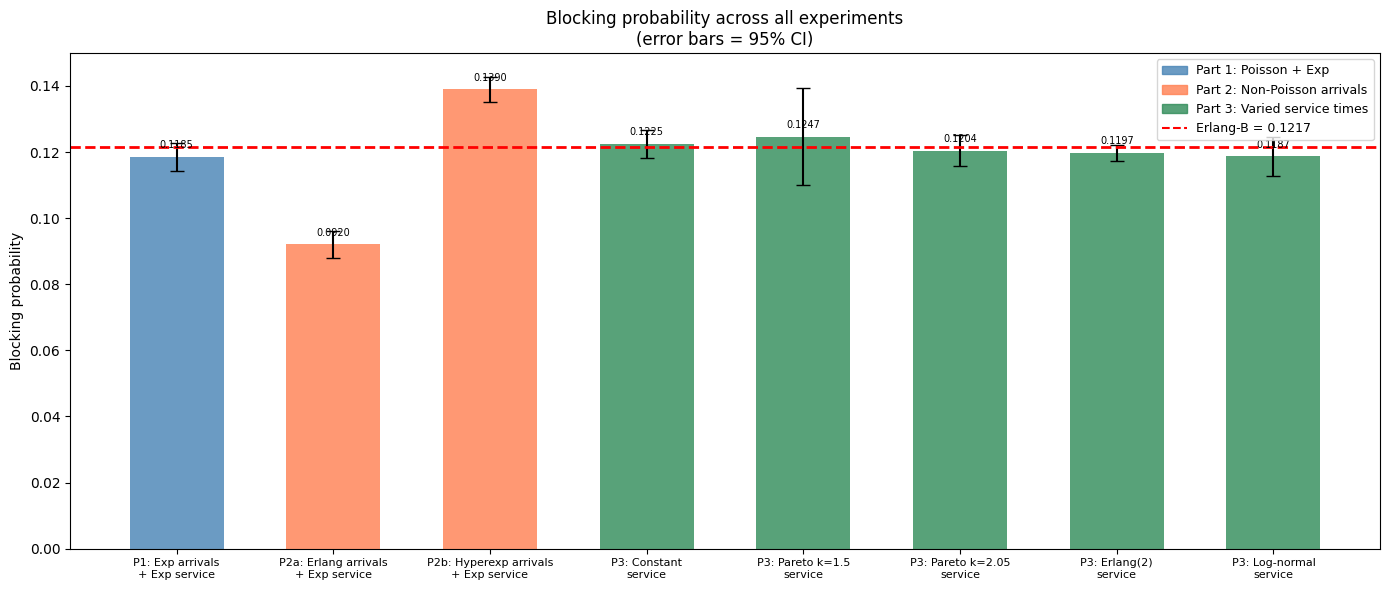

Experiment                            B mean                 95% CI
P1: Exp arrivals + Exp service        0.1185  [0.1142, 0.1228]
P2a: Erlang arrivals + Exp service    0.0920  [0.0880, 0.0961]
P2b: Hyperexp arrivals + Exp service   0.1390  [0.1351, 0.1428]
P3: Constant service                  0.1225  [0.1183, 0.1268]
P3: Pareto k=1.5 service              0.1247  [0.1099, 0.1394]
P3: Pareto k=2.05 service             0.1204  [0.1158, 0.1251]
P3: Erlang(2) service                 0.1197  [0.1173, 0.1222]
P3: Log-normal service                0.1187  [0.1128, 0.1245]
-----------------------------------------------------------------
Erlang-B exact                        0.1217


In [10]:
# Collect all results
all_results = {
    "P1: Exp arrivals\n+ Exp service":        (mean_p1,  lo_p1,  hi_p1),
    "P2a: Erlang arrivals\n+ Exp service":    (mean_erl, lo_erl, hi_erl),
    "P2b: Hyperexp arrivals\n+ Exp service":  (mean_hyp, lo_hyp, hi_hyp),
    "P3: Constant\nservice":                  results_p3_fixed["Constant"][:3],
    "P3: Pareto k=1.5\nservice":              results_p3_fixed["Pareto k=1.5"][:3],
    "P3: Pareto k=2.05\nservice":             results_p3_fixed["Pareto k=2.05"][:3],
    "P3: Erlang(2)\nservice":                 results_p3_fixed["Erlang(2)"][:3],
    "P3: Log-normal\nservice":                results_p3_fixed["Log-normal"][:3],
}

labels = list(all_results.keys())
means  = np.array([all_results[k][0] for k in labels])
los    = np.array([all_results[k][1] for k in labels])
his    = np.array([all_results[k][2] for k in labels])

# Error bars must be positive: distance from mean to CI bounds
err_lo = np.abs(means - los)
err_hi = np.abs(his - means)

colors = (['steelblue'] +
          ['coral', 'coral'] +
          ['seagreen']*5)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(labels))
bars = ax.bar(x, means, color=colors, alpha=0.8, width=0.6)
ax.errorbar(x, means, yerr=[err_lo, err_hi], fmt='none',
            color='black', capsize=5, linewidth=1.5)
ax.axhline(B_exact, color='red', linestyle='--',
           linewidth=2, label=f'Erlang-B exact = {B_exact:.4f}')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Blocking probability')
ax.set_title('Blocking probability across all experiments\n'
             '(error bars = 95% CI)')

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.002,
            f'{m:.4f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
legend_patches = [
    Patch(color='steelblue', alpha=0.8, label='Part 1: Poisson + Exp'),
    Patch(color='coral',     alpha=0.8, label='Part 2: Non-Poisson arrivals'),
    Patch(color='seagreen',  alpha=0.8, label='Part 3: Varied service times'),
    plt.Line2D([0],[0], color='red', linestyle='--',
               label=f'Erlang-B = {B_exact:.4f}')
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print("=" * 65)
print(f"{'Experiment':<35} {'B mean':>8} {'95% CI':>22}")
print("=" * 65)
for k in all_results:
    m_, l_, h_ = all_results[k]
    label = k.replace('\n', ' ')
    print(f"{label:<35} {m_:>8.4f}  [{l_:.4f}, {h_:.4f}]")
print("-" * 65)
print(f"{'Erlang-B exact':<35} {B_exact:>8.4f}")
print("=" * 65)